# Importing the dependencies

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Data collection and Analysis

In [98]:
# Loading the data from CSV file to our pandas dataframe
insurance_dataset = pd.read_csv('./sample_data/insurance.csv')

In [99]:
# First 5 rows of the dataframe
insurance_dataset.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [100]:
# Last 5 rows of the dataset
insurance_dataset.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [101]:
# number of rows and columns
insurance_dataset.shape

(1338, 7)

In [102]:
# Getting some information about the data set
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [103]:
# Rechecking for null values
insurance_dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# Data Analysis 

In [104]:
# Checking the statistical data
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


C:\Users\USER\AppData\Local\Temp\ipykernel_35632\440846550.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset['age'])


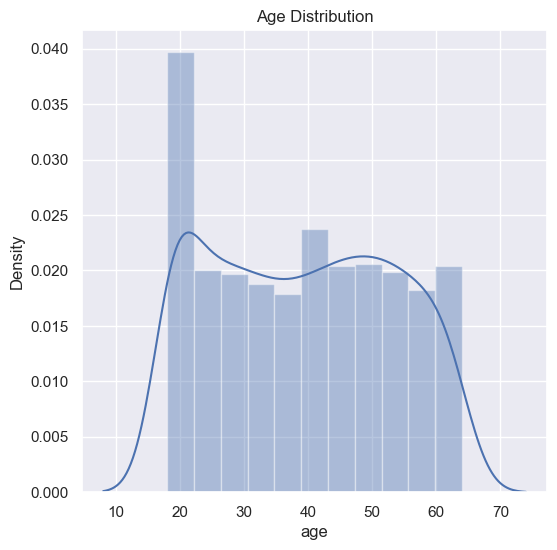

In [105]:
# Finding the distribution of the dataset

# 1. Age

sns.set()
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['age'])
plt.title("Age Distribution")
plt.show()

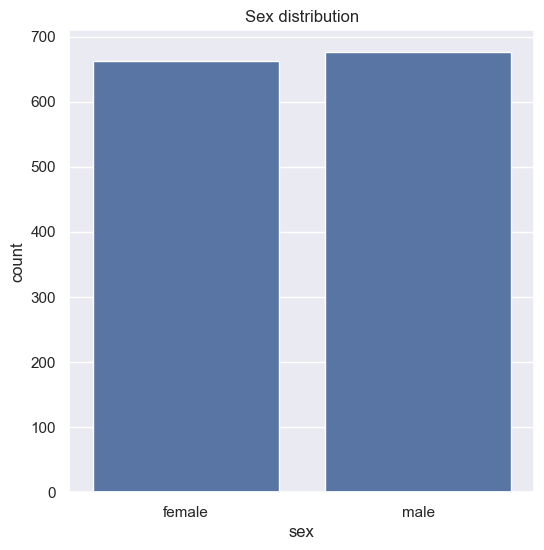

In [106]:
# 2. Gender

plt.figure(figsize=(6,6))
sns.countplot(x='sex', data=insurance_dataset)
plt.title("Sex distribution")
plt.show()

In [107]:
# From the plot above the difference in Gender distribution is very close so we would use another method to get the exact figures

insurance_dataset["sex"].value_counts()



sex
male      676
female    662
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_35632\1082888083.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset['bmi'])


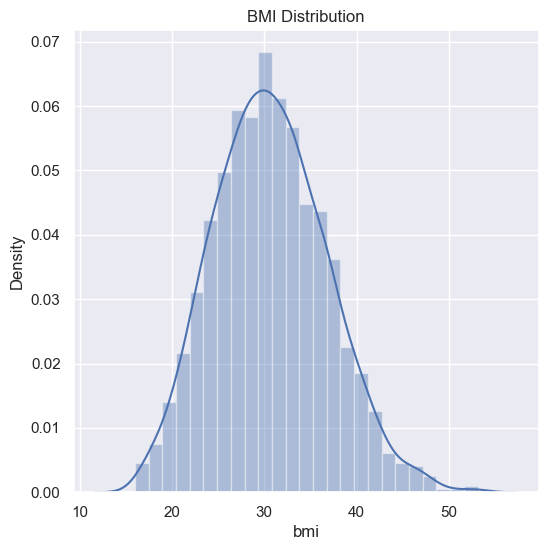

In [108]:
# 3. BMI distribution

plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['bmi'])
plt.title("BMI Distribution")
plt.show()

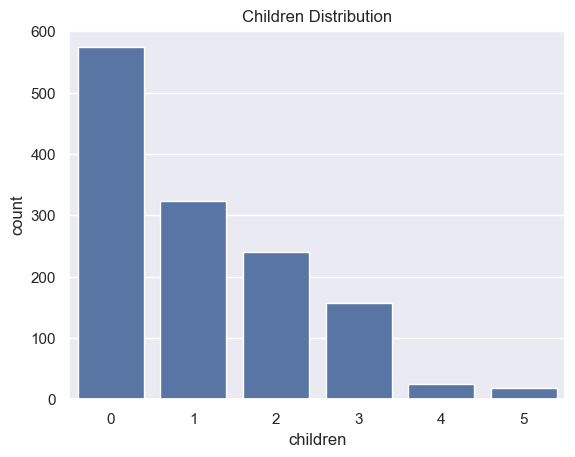

In [109]:
# 4. Children distribution

plt.Figure(figsize=(6,6))
sns.countplot(x='children', data=insurance_dataset)
plt.title("Children Distribution")
plt.show()

In [110]:
insurance_dataset['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

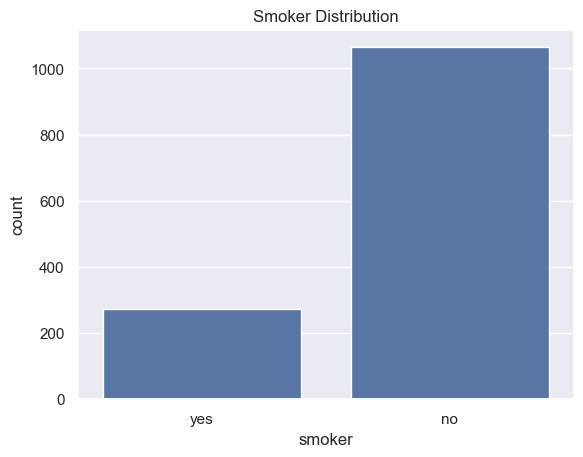

In [111]:
# 5.Smoker distribution

plt.Figure(figsize=(6,6))
sns.countplot(x='smoker', data=insurance_dataset)
plt.title("Smoker Distribution")
plt.show()

In [112]:
insurance_dataset['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

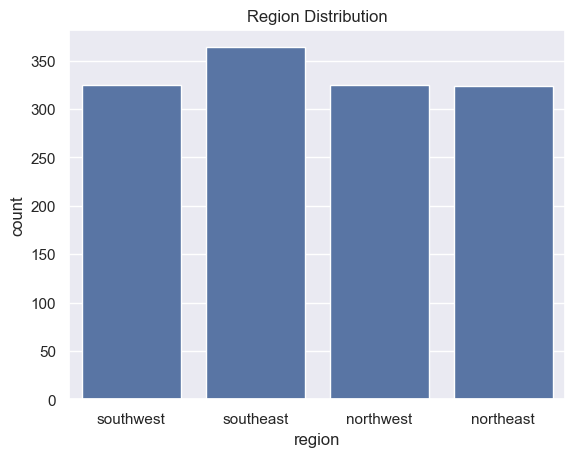

In [113]:
#  6. Region distribution

plt.Figure(figsize=(6,6))
sns.countplot(x='region', data=insurance_dataset)
plt.title("Region Distribution")
plt.show()

In [114]:
insurance_dataset['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_35632\3366191384.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset['charges'])


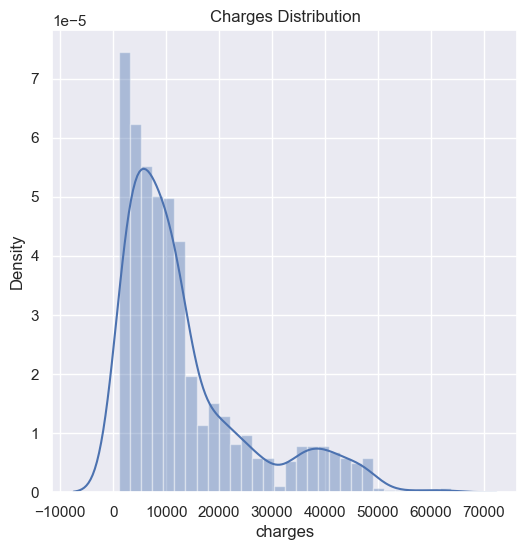

In [115]:
# 7. Charges distibution


plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['charges'])
plt.title("Charges Distribution")
plt.show()

# Data pre-processing 

# Encoding the categorical features 

In [116]:
# Encoding sex columns

insurance_dataset.replace({'sex': {
    'male': 0,
    'female': 1
}}, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_35632\403297827.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'sex': {


In [117]:
# Encoding smoker columns

insurance_dataset.replace({'smoker': {
    'yes': 0,
    'no': 1
}}, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_35632\2578702284.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'smoker': {


In [118]:
# Encoding region columns

insurance_dataset.replace({'region': {
    'southeast': 0,
    'southwest': 1,
    'northeast': 2,
    'northwest': 3,
}}, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_35632\1760445507.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'region': {


In [119]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,1,16884.92400
1,18,0,33.770,1,1,0,1725.55230
2,28,0,33.000,3,1,0,4449.46200
3,33,0,22.705,0,1,3,21984.47061
4,32,0,28.880,0,1,3,3866.85520


# Splitting the features and target 


In [120]:
X = insurance_dataset.drop(columns='charges', axis=1)
Y = insurance_dataset['charges']

In [121]:
print(X)
print(Y)

      age  sex     bmi  children  smoker  region
0      19    1  27.900         0       0       1
1      18    0  33.770         1       1       0
2      28    0  33.000         3       1       0
3      33    0  22.705         0       1       3
4      32    0  28.880         0       1       3
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970         3       1       3
1334   18    1  31.920         0       1       2
1335   18    1  36.850         0       1       0
1336   21    1  25.800         0       1       1
1337   61    1  29.070         0       0       3

[1338 rows x 6 columns]
0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [122]:
# Split the dataset into training data and testing data

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [123]:
print(X.shape, X_train.shape, X_test.shape)

(1338, 6) (1070, 6) (268, 6)


# Model Training 
 

* Linear regression 

In [124]:
# Loading the linear regression model

regressor = LinearRegression()

In [125]:
regressor.fit(X_train, Y_train)

LinearRegression()

# Model Evaluation 

In [126]:
#  Prediction on training data

training_data_prediction = regressor.predict(X_train)

In [127]:
# R squared value


r2_train = metrics.r2_score(Y_train, training_data_prediction)

print("R squared value:", r2_train)

R squared value: 0.751505643411174


In [128]:
#  Prediction on testing data

test_data_prediction = regressor.predict(X_test)

In [129]:
# R squared value


r2_test = metrics.r2_score(Y_test, test_data_prediction)

print("R squared value:", r2_test)

R squared value: 0.7447273869684077


# Persisting the model (so it survives outside this notebook)

In [130]:
import joblib

# save the trained classifier
joblib.dump(regressor, "health_insurance_model.pkl")

# save the column order the model expects (critical for predictions later)
joblib.dump(list(X.columns), "health_insurance_model_columns.pkl")
print("Model and column order saved.")

Model and column order saved.


In [131]:
def predict_insurance_cost(applicant: dict, model=None, columns=None):
    """
    Predict insurance cost for a single applicant

    returns the predicted price of the Health insurance
    """

    if model is None:
        model = joblib.load("health_insurance_model.pkl")
    if columns is None:
        columns = joblib.load("health_insurance_model_columns.pkl")

    # Encodings used during training
    gender_map = {"male": 0, "female": 1}
    smoker_map = {'yes': 0, "no": 1}
    region_map = {
        'southeast': 0,
        'southwest': 1,
        'northeast': 2,
        'northwest': 3,
    }

    row={
        "age": applicant["age"],
        "sex": gender_map[applicant["sex"]],
        "bmi": applicant["bmi"],
        "children": applicant["children"],
        "smoker": smoker_map[applicant["smoker"]],
        "region": region_map[applicant["region"]]
    }


    # build the feature vector in the exact column order the model was trained on
    input_df = pd.DataFrame([row])[columns]

    prediction = model.predict(input_df)[0]
    return f"Approximate Price: ${prediction}"



# Example
sample_applicant = {
    "age": 19,
    "sex": "female",
    "bmi": 27.900,
    "children": 0,
    "smoker": "yes",
    "region": "southwest"
}

model = joblib.load("health_insurance_model.pkl")
result = predict_insurance_cost(sample_applicant, model=model, columns=list(X.columns))
print("Health Insurance Cost:", result)




Health Insurance Cost: Approximate Price: $25597.739413468422
